In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

In [8]:
archivo_excel = Path(r"C:/Users/Usuario/Desktop/Charla Data Science/Librerias/PRACTICAS/MisVentas-S1-2021.xlsx")
df = pd.read_excel(archivo_excel, sheet_name = 5) #la hoja 6 siempre es n-1

df.head()

,NumeroVenta,Fecha de Venta,Codigo Tipo Producto,Producto,Cantidad,Precio,Total,Vendedor,Ciudad,Local,Proveedor,NomVendedor,NomCiudad,TipoProducto,NomLocal
0,1,2019-03-29,1,Papas fritas Saladas,74,500,37000,3,1,1,1,Maria Donoso,Santiago,Papas Fritas,Centro
1,2,2019-03-30,1,Papas fritas Bravas,115,500,57500,2,1,1,4,Ana Toledo,Santiago,Papas Fritas,Centro
2,3,2019-04-09,1,Papas fritas salsa,41,500,20500,1,2,2,1,Pedro Arias,Constitución,Papas Fritas,Sur
3,4,2019-04-13,1,Papas fritas Dulces,56,500,28000,4,6,4,1,Luis Pizarro,Talca,Papas Fritas,Poniente
4,5,2019-04-16,1,Papas fritas Saladas,25,500,12500,4,6,4,1,Luis Pizarro,Talca,Papas Fritas,Poniente


In [9]:
print (df.shape) #pandas
print (df.size) #numpy

print (f"\ntipo de datos:\n",df.dtypes)

print ("\n información de los datos:")
print (df.info())


(45, 15)
675

tipo de datos:
 NumeroVenta                      int64
Fecha de Venta          datetime64[ns]
Codigo Tipo Producto             int64
Producto                        object
Cantidad                         int64
Precio                           int64
Total                            int64
Vendedor                         int64
Ciudad                           int64
Local                            int64
Proveedor                        int64
NomVendedor                     object
NomCiudad                       object
TipoProducto                    object
NomLocal                        object
dtype: object

 información de los datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   NumeroVenta           45 non-null     int64         
 1   Fecha de Venta        45 non-null     datetime64[ns]
 2   Cod

In [10]:
#cuántas veces aparece un cierto vendedor
print (df.Vendedor.value_counts())

#nombre de los distintos vendedores en orden (nunique con pd, o len con np antes del array)
print (np.sort(df.Vendedor.unique()))

#descriptivos de los vendedores
print (df.Vendedor.describe())

Vendedor
4    10
3     9
5     8
1     5
2     5
6     4
7     4
Name: count, dtype: int64
[1 2 3 4 5 6 7]
count    45.000000
mean      3.866667
std       1.739906
min       1.000000
25%       3.000000
50%       4.000000
75%       5.000000
max       7.000000
Name: Vendedor, dtype: float64


In [11]:
#variable a describir
variable_info = df["Total"]

# Frecuencia absoluta
indice = variable_info.value_counts().sort_index()

# Frecuencia relativa
indice_relativo = variable_info.value_counts(normalize=True).sort_index()

# Frecuencia acumulada
indice_acumulado = indice.cumsum()

# Frecuencia relativa acumulada
indice_relativo_acumulado = indice_relativo.cumsum()

# Crear DataFrame de la tabla de frecuencias
tabla_frecuencias = pd.DataFrame({
    "I": indice.index,
    "ni": indice.values,
    "fi": indice_relativo.values,
    "Ni": indice_acumulado.values,
    "Fi": indice_relativo_acumulado.values
})

print(tabla_frecuencias)



        I  ni        fi  Ni        Fi
0    3000   2  0.044444   2  0.044444
1    3300   2  0.044444   4  0.088889
2    5000   3  0.066667   7  0.155556
3   11500   5  0.111111  12  0.266667
4   12500   6  0.133333  18  0.400000
5   20500   5  0.111111  23  0.511111
6   28000   6  0.133333  29  0.644444
7   37000  12  0.266667  41  0.911111
8   42000   1  0.022222  42  0.933333
9   46000   2  0.044444  44  0.977778
10  57500   1  0.022222  45  1.000000


## Interpretación de tablas de frecuencia
---

<font color="magenta"> **Ventas** </font>

- *En cuánto a ventas (N7 por ejemplo), quiere decir que 29 ventas (porque la tabla está a nivel de ventas) fueron hechas pagando un precio hasta $28.000.*
*Ó dicho de otra forma, 29 ventas fueron entre $3.000 y $28.000*  
- *n9, quiere decir que 2 ventas fueron de $46.000. representando un 4% de las ventas totales*  
---

<font color="magenta"> **Vendedores** </font>

- *N3, quiere decir que 19 ventas (porque la tabla está a nivel de ventas) fueron realizadas por los vendedores 1, 2 y 3 en conjunto.*  
- *n4, quiere decir que el vendedor 4 hizo 10 ventas, representando un 22% de las ventas totales.*  




In [12]:
#Percentiles
print ("El 50% de las ventas fue a lo más: ", np.percentile(df.Total,50))
print ("El 26% de las ventas fue a lo más: ", np.percentile(df.Total,26))

El 50% de las ventas fue a lo más:  20500.0
El 26% de las ventas fue a lo más:  11940.000000000002


## Distribución binomial
instalar scipy

from scipy.stats import binom

---

#### Ejercicio:

- Imagine que toma los datos de la población de Talca, y esta tiene 150 mil habitantes, usted sabe 15 mil personas estudian gratis, o sea el 10% (p), ¿qué tan probable es que por cada 10 personas (n), 2 estudien gratis (k)?

**Probabilidad puntual P(X = 2)**
*Probabilidad de que 2 personas de 10 estudien gratis*
- binom.pmf(k, n, p) (probability mass function)

**Probabilidad acumulada P(X <= 2)**
*Probabilidad de que a lo más 2 personas de 10 estudien gratis*
- binom.cdf(k, n, p) (cumulative distribution function)


In [1]:
%pip install scipy
from scipy.stats import binom

Note: you may need to restart the kernel to use updated packages.


In [4]:
print (binom.pmf(2,10,0.1))

print (binom.cdf(2,10,0.1))

0.19371024450000007
0.9298091735999999


#### Test de hipótesis
*Primero: Comparar el promedio de ventas del vendedor 2 y el 5 y ver su diferencia*

*Segundo: Evaluar si realmente son significativas estas diferencias o no.*
*Por ejemplo: 
- H0: medias iguales
- H1: medias diferentes

Si p-value < 0,05 se puede decir que hay evidencia estadística que comprueba que no fue al azar esta diferencia, o sea que dada la cantidad de datos y valores de estos, la variabilidad es muy pequeña (desvest es mínimo en comparación lo mencionado)

**Si es paramétrico, usar ttest_ind**

**Si no es paramétrico, usar mannwhitneyu alternative two-sided**


El estadístico es: 0.9221892050672643 
El valor p es: 0.005019177464401219


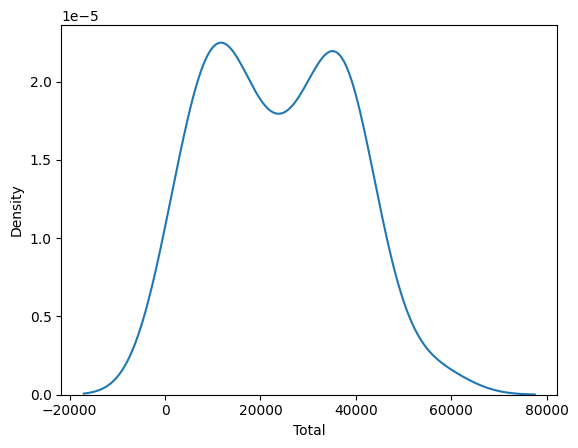

In [ ]:
import seaborn as sns

#ver distribución de los datos
sns.kdeplot(df.Total)

#test paramétrico para verificar normalidad (H0: distribución paramétrica)
from scipy.stats import shapiro
estadistico, p_value = (shapiro(df.Total))
print (f"\nEl estadístico es: {estadistico} \nEl valor p es: {p_value}")

media_vendedor2 = df[df.Vendedor == 2].Total
media_vendedor5 = df[df.Vendedor == 5].Total

#### Análisis de la distribución gráfica anterior

*Dada la evidencia de una distribución bimodal en el total de ventas (caracterizada por la presencia de dos modas o máximos relativos), se infiere que la muestra probablemente proviene de una población heterogénea. específicamente, esta configuración estadística sugiere la existencia de al menos dos segmentos de clientes distintos con patrones de gasto o transacciones fundamentalmente diferentes, lo que resulta en dos concentraciones de valor bien definidas.*

In [ ]:
#Test de hipótesis sobre la media paramétrico
from scipy.stats import ttest_ind

stat, p_val = ttest_ind (media_vendedor2, media_vendedor5)

print (f"\n el estadístico es: {t_stat} \n y el p-value es: {p_val}")

#Las medias enteriores para el vendedor 2 son de 18.000 y para el vendedor 5 son de 38.000 aprox, si son diferentes pero test no lo muestra así debido a que son muestras muy pequeñas


 el estadístico es: 2.0926118533369573 
 y el p-value es: 0.06036729925968728

 Vendedor
4    10
3     9
5     8
1     5
2     5
6     4
7     4
Name: count, dtype: int64


In [50]:
# Test no paramétrico hipótesis sobre la media (two-sided: probar diferencias, greater: si el primero es mas grande que el segundo --H0: iguales, less: al revés de greater)

from scipy.stats import mannwhitneyu
stat, p_val = mannwhitneyu (media_vendedor2, media_vendedor5, alternative='greater')

print(f"Estadístico U: {stat}")
print(f"P-valor: {p_val}")

print (df[df.Vendedor==2]['Total'].sum())
print (df[df.Vendedor==5]['Total'].sum())

Estadístico U: 33.0
P-valor: 0.032325418045082314
190000
144300


#### Correlación
---
*Pearson: lineal paramétrica, Spearman: No paramétrica, Kendall: No paramétrica conservadora*

0.987470285702134


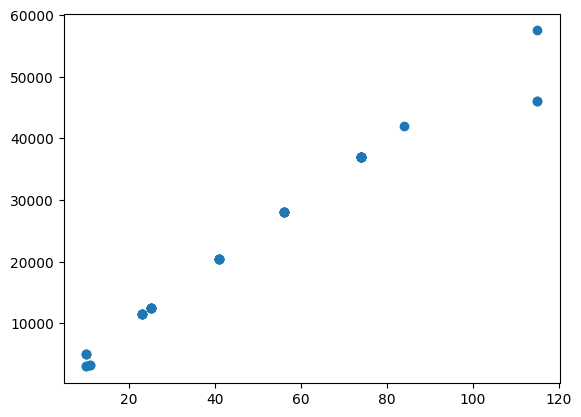

In [49]:
#Correlación entre variables Cantidad y Total (de ventas)
cor_ventas = df.Cantidad
cor_total = df.Total
print (cor_ventas.corr(cor_total))

import matplotlib.pyplot as plt

plt.scatter(df['Cantidad'], df['Total'])
